In [ ]:
import pandas as pd

df = pd.read_csv("jobstreet_all_job_dataset.csv", engine='python', on_bad_lines='skip')
df.head()

,job_id,job_title,company,descriptions,location,category,subcategory,role,type,salary,listingDate
0,74630583.0,Procurement Executive (Contract),Coca-Cola Bottlers (Malaysia) Sdn Bhd,Position Purpose\nManage aspects of procuremen...,Negeri Sembilan,"Manufacturing, Transport & Logistics","Purchasing, Procurement & Inventory",procurement-executive,Contract/Temp,NaN,2024-03-21T05:58:35Z
1,74660602.0,Account Executive/ Assistant,Acoustic & Lighting System Sdn Bhd,We are looking for a Account Executive/ Assist...,Petaling,Accounting,Bookkeeping & Small Practice Accounting,executive-assistant,Full time,"RM 2,800 – RM 3,200 per month",2024-03-22T06:52:57Z
2,74655679.0,"Data Analyst - Asset Management, SPX Express",Shopee Mobile Malaysia Sdn Bhd,Performs detailed data analysis on existing sp...,Klang District,"Manufacturing, Transport & Logistics",Analysis & Reporting,asset-management-analyst,Full time,NaN,2024-03-22T04:22:43Z
3,74657624.0,Service Engineer,Sun Medical Systems Sdn Bhd,"You are important for troubleshooting, install...",Petaling,Engineering,Electrical/Electronic Engineering,services-engineer,Full time,"RM 3,000 – RM 3,500 per month",2024-03-22T05:32:09Z
4,74679363.0,Purchasing Executive,Magnet Security & Automation Sdn. Bhd.,"MAG is a trailblazer in the industry, boasting...",Hulu Langat,"Manufacturing, Transport & Logistics","Purchasing, Procurement & Inventory",purchasing-executive,Full time,"RM 2,800 – RM 3,500 per month",2024-03-23T03:56:39Z


The dataset was loaded using the Pandas library and an initial inspection was conducted to understand its structure and features.

In [ ]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69024 entries, 0 to 69023
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   job_id        69024 non-null  float64
 1   job_title     69024 non-null  object 
 2   company       69024 non-null  object 
 3   descriptions  69024 non-null  object 
 4   location      69024 non-null  object 
 5   category      69024 non-null  object 
 6   subcategory   69024 non-null  object 
 7   role          66772 non-null  object 
 8   type          69024 non-null  object 
 9   salary        31594 non-null  object 
 10  listingDate   69024 non-null  object 
dtypes: float64(1), object(10)
memory usage: 5.8+ MB


Dataset dimensions and data types were examined to identify numerical and categorical features as well as potential data quality issues.

In [ ]:
df.isnull().sum()
df = df.dropna()

Records containing missing values were removed to ensure data completeness and consistency.

In [ ]:
df.duplicated().sum()
df = df.drop_duplicates()

Deleting duplicates

In [ ]:
df = df[['location', 'category', 'listingDate']]

Text-heavy fields (job title, description, company) do not contribute to forecasting job counts and are removed.


In [ ]:
df['listingDate'] = pd.to_datetime(df['listingDate'])
df['year'] = df['listingDate'].dt.year
df['month'] = df['listingDate'].dt.month

Job demand changes over time; extracting temporal features enables forecasting.

In [ ]:
monthly_jobs = (
    df.groupby(['location', 'year', 'month'])
      .size()
      .reset_index(name='job_count')
)

monthly_jobs.head()

,location,year,month,job_count
0,Alam Damai,2024,3,3
1,Alor Gajah District,2024,2,1
2,Alor Gajah District,2024,3,4
3,Ampang,2024,2,1
4,Ampang,2024,3,6


In [ ]:
monthly_jobs_encoded = pd.get_dummies(
    monthly_jobs,
    columns=['location'],
    drop_first=True
)

Location is categorical and must be encoded numerically for machine learning models.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
monthly_jobs_encoded[['year', 'month']] = scaler.fit_transform(
    monthly_jobs_encoded[['year', 'month']]
)

Feature Scaling

In [ ]:
from sklearn.decomposition import PCA

X = monthly_jobs_encoded.drop('job_count', axis=1)
y = monthly_jobs_encoded['job_count']

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X)

Data Reduction using PCA

## **Machine Learning Models**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

Convert job_count to Hotspot category (3 classes using percentile)

In [ ]:
high_threshold = np.percentile(y, 70)
low_threshold = np.percentile(y, 30)

def categorize_demand(count):
    if count >= high_threshold:
        return "High"
    elif count <= low_threshold:
        return "Low"
    else:
        return "Medium"

monthly_jobs_encoded['demand_level'] = monthly_jobs_encoded['job_count'].apply(categorize_demand)


Classification target

In [ ]:
y = monthly_jobs_encoded['demand_level']

Classification Features

In [ ]:
X = monthly_jobs_encoded.drop(['job_count', 'demand_level'], axis=1)

Applying PCA for Classification

In [ ]:
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X)

Training Models

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42, stratify=y)

models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVC": SVC(),
    "kNN": KNeighborsClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"{name}:")
    print(f"   Accuracy: {acc:.3%}")
    print(f"   F1-Score: {f1:.3%}")

Logistic:
   Accuracy: 50.000%
   F1-Score: 45.875%
Decision Tree:
   Accuracy: 50.000%
   F1-Score: 48.536%
Random Forest:
   Accuracy: 47.222%
   F1-Score: 44.233%
SVC:
   Accuracy: 55.556%
   F1-Score: 47.820%
kNN:
   Accuracy: 50.000%
   F1-Score: 42.286%
Gradient Boosting:
   Accuracy: 44.444%
   F1-Score: 43.961%


In [ ]:
models= {
    "Logistic": {
        'model': LogisticRegression(max_iter=1000),
        'params': {'C': [0.1, 1, 10]}
    },
    "Decision Tree": {
        'model': DecisionTreeClassifier(random_state=42),
        'params': {'max_depth': [None, 5, 10], 'min_samples_split': [2, 5], 'min_samples_leaf': [1, 2]}
    },
    "Random Forest": {
        'model': RandomForestClassifier(random_state=42, n_jobs=-1),
        'params': {'n_estimators': [100, 200], 'max_depth': [None, 5, 10], 'min_samples_split': [2, 5]}
    },
    "SVC": {
        'model': SVC(max_iter=5000),
        'params': {'C': [0.1, 1, 10]}
    },
    "kNN": {
        'model': KNeighborsClassifier(),
        'params': {'n_neighbors': [3, 5, 7], 'weights': ['uniform', 'distance']}
    },
    "Gradient Boosting": {
        'model': GradientBoostingClassifier(),
        'params': {'n_estimators': [100, 200], 'learning_rate': [0.01, 0.1], 'max_depth': [3, 5]}
    }
}


for name, m in models.items():
    grid = GridSearchCV(m['model'], m['params'], cv=3, scoring='f1_weighted', n_jobs=-1)
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"{name}:")
    print(f"   Best Params: {grid.best_params_}")
    print(f"   Accuracy: {acc:.3%}")
    print(f"   F1-Score: {f1:.3%}")
    print("------")


Logistic:
   Best Params: {'C': 0.1}
   Accuracy: 66.667%
   F1-Score: 61.321%
------
Decision Tree:
   Best Params: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2}
   Accuracy: 66.667%
   F1-Score: 61.321%
------
Random Forest:
   Best Params: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
   Accuracy: 44.444%
   F1-Score: 40.377%
------
SVC:
   Best Params: {'C': 10}
   Accuracy: 47.222%
   F1-Score: 42.512%
------
kNN:
   Best Params: {'n_neighbors': 7, 'weights': 'uniform'}
   Accuracy: 47.222%
   F1-Score: 42.512%
------
Gradient Boosting:
   Best Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
   Accuracy: 47.222%
   F1-Score: 49.275%
------


Confusion Matrix

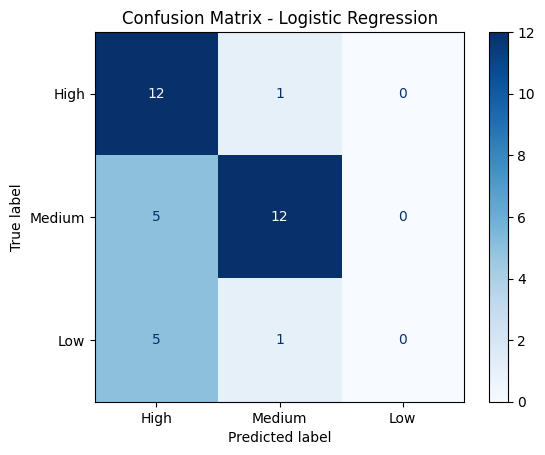

In [ ]:
best_model = LogisticRegression(C=0.1, max_iter=1000)

best_model.fit(X_train, y_train)

y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["High", "Medium", "Low"])

disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


Visualization

In [ ]:
import pandas as pd
import plotly.express as px

df['location'] = df['location'].str.strip()

location_demand = df.groupby('location').size().reset_index(name='job_count')

top_locations = location_demand.sort_values('job_count', ascending=False).head(10)

fig = px.bar(
    top_locations,
    x='job_count',
    y='location',
    orientation='h',
    color='job_count',
    color_continuous_scale='YlOrRd',
    title='Top 10 Job Hotspots in Malaysia'
)

fig.update_layout(yaxis=dict(autorange="reversed"))
fig.show()

In [ ]:
df['location'] = df['location'].str.strip().str.title()

location_totals = df.groupby('location').size().reset_index(name='total_jobs')

top_locations = location_totals.sort_values('total_jobs', ascending=False).head(5)['location']

filtered_df = df[df['location'].isin(top_locations)]

treemap_data = filtered_df.groupby(['location', 'category']).size().reset_index(name='job_count')

fig = px.treemap(
    treemap_data,
    path=['location', 'category'],
    values='job_count',
    color='job_count',
    color_continuous_scale='YlOrRd',
    title='Job Demand Hotspots by Location and Category'
)

fig.show()

In [ ]:
y_pred_all = best_model.predict(X)

monthly_jobs['predicted_class'] = y_pred_all

In [ ]:
import pandas as pd
import plotly.express as px

predicted_hotspots = (
    monthly_jobs.groupby('location')['predicted_class']
    .count()
    .reset_index(name='predicted_count')
)

top_predicted = predicted_hotspots.sort_values(
    'predicted_count', ascending=False
).head(10)

fig = px.bar(
    top_predicted,
    x='predicted_count',
    y='location',
    orientation='h',
    color='predicted_count',
    color_continuous_scale='YlOrRd',
    title='Top 10 Predicted Job Hotspots in Malaysia'
)

fig.update_layout(yaxis=dict(autorange="reversed"))
fig.show()


In [ ]:
df['listingDate'] = pd.to_datetime(df['listingDate'])
df['year'] = df['listingDate'].dt.year
df['month'] = df['listingDate'].dt.month

# Group by location, category, year, and month for combined forecasting
combined_monthly_jobs = (
    df.groupby(['location', 'category', 'year', 'month'])
    .size()
    .reset_index(name='job_count')
)


In [ ]:
combined_encoded = pd.get_dummies(combined_monthly_jobs, columns=['location', 'category'], drop_first=True)

X = combined_encoded.drop('job_count', axis=1)
y = combined_encoded['job_count']


In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X, y)


RandomForestRegressor(n_estimators=200, random_state=42)

In [ ]:
locations = df['location'].unique()
categories = df['category'].unique()

future_data = []

for loc in locations:
    for cat in categories:
        for month in range(1, 13):
            future_data.append({
                'location': loc,
                'category': cat,
                'year': 2026,
                'month': month
            })

future_df = pd.DataFrame(future_data)


In [ ]:
future_encoded = pd.get_dummies(future_df, columns=['location', 'category'], drop_first=True)
future_encoded = future_encoded.reindex(columns=X.columns, fill_value=0)

future_df['predicted_job_count'] = model.predict(future_encoded)


In [ ]:
import plotly.express as px

future_totals = (
    future_df.groupby('category')['predicted_job_count']
    .sum()
    .reset_index()
    .sort_values('predicted_job_count', ascending=False)
)

fig = px.bar(
    future_totals.head(10),
    x='predicted_job_count',
    y='category',
    orientation='h',
    color='predicted_job_count',
    color_continuous_scale='YlOrRd',
    title='Predicted Job Category Demand (2026 Forecast)'
)

fig.update_layout(yaxis=dict(autorange="reversed"))
fig.show()
